In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm
from matplotlib.lines import Line2D

# ensure figures render inline
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110})

# data paths
import pathlib
DATA = pathlib.Path("data")


# The Relative GLV: a growing disordered economy

## What this notebook is

The *relative generalised Lotka-Volterra* (GLV) model is a disordered replicator
in which firms compete with one another but interactions act on the **mean firm**
rather than on the aggregate.  This single modification to the classic GLV removes
the finite-time blow-up that plagues the standard model and produces a
self-consistently growing economy -- aggregate output $M(t) = \sum_i x_i(t)$
grows exponentially without tuning.

The central claim is that this model, with no extra ingredients, simultaneously
reproduces two empirical regularities of firm growth documented by
Moran, Santos, and Bouchaud (MSB, 2024):

1. The cross-sectional distribution of (rescaled) growth rates is **symmetric and
   fat-tailed** -- closer to a Laplace than a Gaussian.
2. The growth volatility of individual firms **declines with size** as
   $\sigma(S) \sim S^{-\beta}$ with $\beta \approx 0.15$--$0.20$.

The model also admits a mean-field (DMFT) solution that is exact in the
high-connectivity limit.  The full derivation is in
`glv/docs/superpowers/specs/2026-06-21-relative-glv-dmft-derivation.md`.

> **Note on scope.** The MSB paper uses these two facts to *reject* simpler
> granular models of firm growth and points toward size-growing correlations as
> the mechanism.  The relative GLV is presented here as a candidate mechanism
> -- a minimal model that reproduces the facts -- not as the definitive
> explanation of real-world firm growth.


## The target: two MSB stylized facts

Let $S_i(t) = N x_i(t) / M(t)$ be the **relative size** of firm $i$ (normalised
so that the average firm has size 1).  The annual log-growth rate is

$$g_i = \Delta \ln S_i = \ln S_i(t+1) - \ln S_i(t).$$

**Fact 1 (tent-shaped growth distribution).**  After rescaling by
$\sqrt{\pi/2} \cdot \mathrm{MAD}$ (robust to heavy tails),
the empirical PDF of $g_i$ is symmetric and fat-tailed:

$$p(g) \sim e^{-|g|/b}, \qquad \text{(Laplace-like, not Gaussian)}.$$

Quantified by Bowley skewness $\approx 0$ and excess kurtosis $\gg 0$.

**Fact 2 (size-variance power law).**  Firms with larger average size have lower
growth volatility:

$$\sigma_i \sim \bar{S}_i^{-\beta}, \qquad \beta_{\rm emp} \approx 0.15\text{--}0.20.$$

MSB report $\beta \approx 0.20 \pm 0.01$ (MAD-based estimator).


## The model

### Equations of motion

Each firm $i$ obeys

$$\dot x_i = x_i \!\left[1 - \frac{x_i}{m} - \frac{(\alpha x)_i}{m}\right],
\qquad m = \frac{M}{N} = \langle x \rangle,$$

where $\alpha_{ij}$ is a disordered interaction matrix drawn from a sparse
power-law graph with mean competition $\mu > 0$ and disorder $\sigma$.

### Share + log-scale split

Writing $x_i = M w_i$ with shares $w_i = x_i/M$ on the simplex, the dynamics
decouple into a **replicator** for the shares and a **linear equation** for the
log-aggregate:

$$\dot w_i = w_i(f_i - \bar f) + \lambda(N^{-1} - w_i), \qquad
  \frac{d \ln M}{dt} = \bar f,$$

where $f_i = 1 - N w_i - N(\alpha w)_i$ is firm $i$'s fitness,
$\bar f = \sum_j w_j f_j$ is the mean fitness (= aggregate growth rate $g_{\rm eff}$),
and $\lambda \geq 0$ is a small immigration floor that prevents condensation.

Because $M$ never appears in the share equations, we integrate $w$ and $\ln M$
separately: $w$ stays on the simplex and $\ln M$ grows linearly.
Nothing overflows even as $M \to \infty$.

### Relative firm sizes

The relative size $S_i = N w_i$ has mean 1 by construction.
Growth rates $g_i = \Delta \ln S_i$ are **purely idiosyncratic**: the common
drift $g_{\rm eff} = \dot{\ln M}$ cancels, exactly as in the empirical
definition.


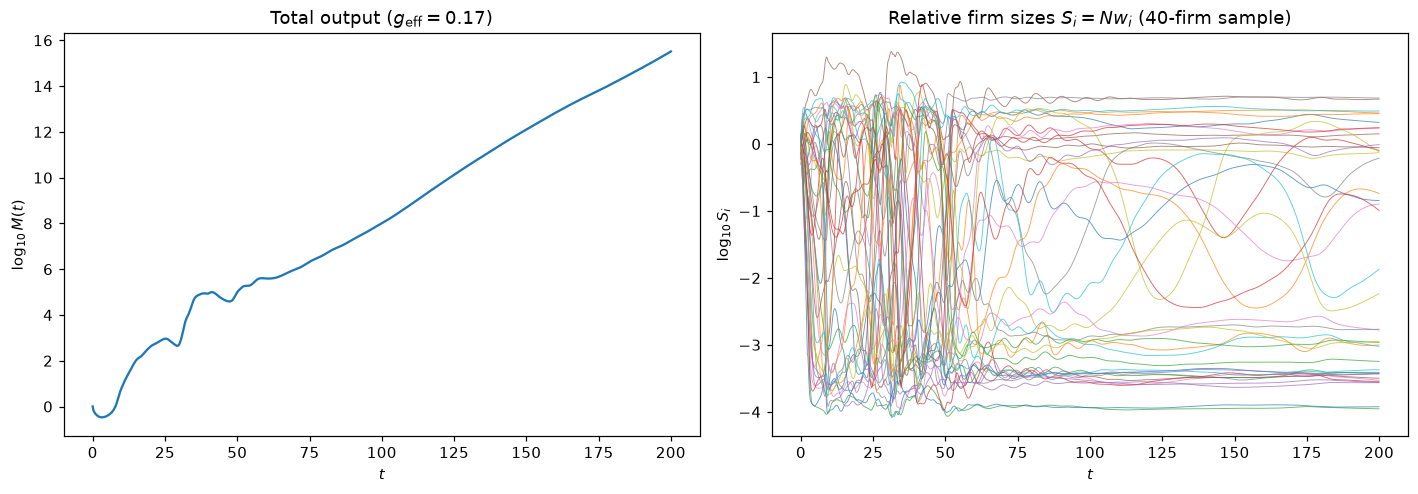

g_eff = 0.172 | surviving firms: 680 / 1200


In [2]:
from relative_glv import coupling, integrate, growth_rate

# Live small simulation: N=1200, power-law graph, chaotic/growing regime
a = coupling(1200, mu=1.76, sigma=1.75, kind="powerlaw", seed=0)
r = integrate(a, tmax=200, n_eval=1000, lam=1e-3, seed=0,
              method="RK45", rtol=1e-4, atol=1e-7)

t, W, lnM = r["t"], r["W"], r["lnM"]
g_eff = growth_rate(t, lnM)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# left: aggregate output M(t) growing
ax[0].plot(t, lnM / np.log(10), color="C0")
ax[0].set(xlabel="$t$", ylabel=r"$\log_{10} M(t)$",
          title=f"Total output ($g_{{\\mathrm{{eff}}}}={g_eff:.2f}$)")

# right: relative sizes S_i = N w_i for a random sample of firms
rng = np.random.default_rng(42)
sample = rng.choice(W.shape[0], size=min(40, W.shape[0]), replace=False)
N_sim = W.shape[0]
for i in sample:
    ax[1].plot(t, np.log10(np.maximum(N_sim * W[i], 1e-8)), lw=0.6, alpha=0.7)
ax[1].set(xlabel="$t$", ylabel=r"$\log_{10} S_i$",
          title=r"Relative firm sizes $S_i = N w_i$ (40-firm sample)")

plt.tight_layout()
plt.show()
print(f"g_eff = {g_eff:.3f} | surviving firms: {int((W[:, -1] > 1e-6).sum())} / {N_sim}")


## MSB facts in the model

We load precomputed statistics from a large-$N$ run ($N = 4000$, many economies)
stored in `data/msb.npz`.

### Size-volatility relation

Per firm, define the **mean size** $\bar S_i$ and the **MAD-based volatility**

$$\sigma_i = \sqrt{\frac{\pi}{2}} \cdot \langle |g_i - \langle g_i \rangle| \rangle,$$

which equals the std for a Gaussian but is robust to heavy tails.
Bin firms by $\bar S_i$, take the median $\sigma$ in each bin, and fit the
log-log slope on the decline branch (right of the floor/plateau):

$$\hat\beta = -\frac{d \log \sigma}{d \log \bar S}\bigg|_{\text{large-}S}.$$


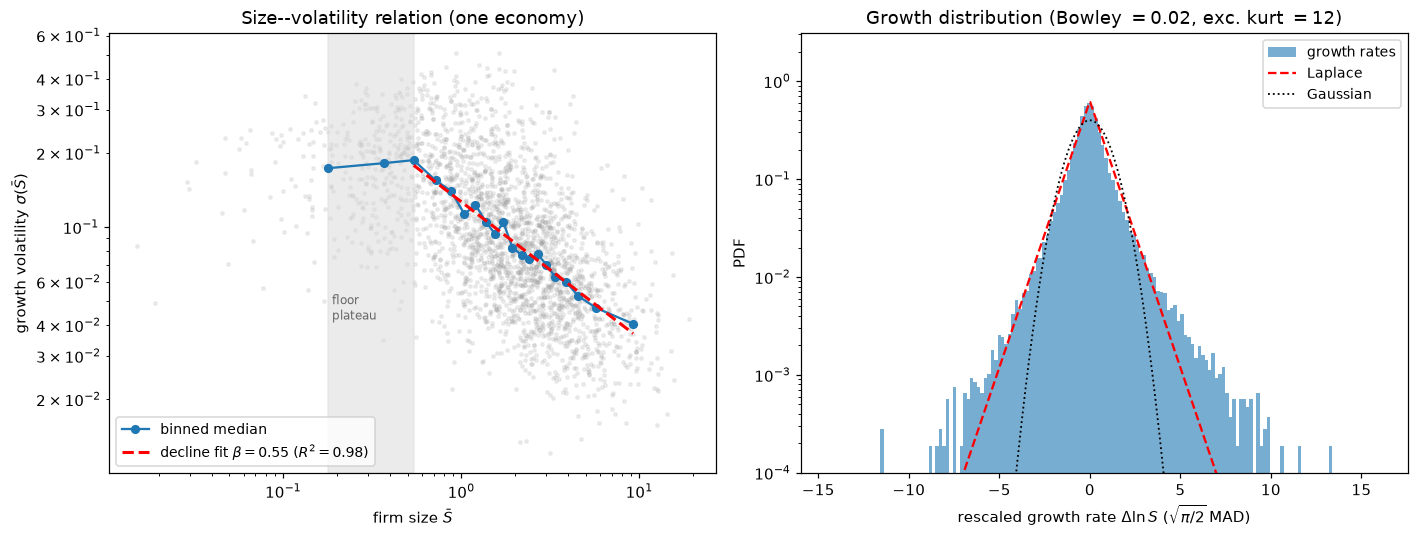

beta=0.554  R2=0.980  Bowley=0.017  excess_kurtosis=12.2


In [3]:
d = np.load(DATA / "msb.npz", allow_pickle=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# ---- panel 1: size-volatility ----
svS = d["msb_sv_S"].astype(float)
svV = d["msb_sv_vol"].astype(float)
bx  = d["msb_bin_S"].astype(float)
by  = d["msb_bin_vol"].astype(float)
pk  = int(d["msb_pk"])
beta_val = float(d["msb_beta"])
r2_val   = float(d["msb_r2"])

ax[0].scatter(svS, svV, s=5, alpha=0.15, color="0.6")
ax[0].plot(bx, by, "o-", color="C0", ms=5, label="binned median")
if bx.size > pk + 1:
    c = np.polyfit(np.log10(bx[pk:]), np.log10(by[pk:]), 1)
    xx = np.array([bx[pk], bx[-1]])
    ax[0].plot(xx, 10 ** np.polyval(c, np.log10(xx)), "r--", lw=2,
               label=f"decline fit $\\beta={beta_val:.2f}$ ($R^2={r2_val:.2f}$)")
    ax[0].axvspan(bx[0], bx[pk], color="0.85", alpha=0.5)
    ax[0].text(bx[0], by.min(), " floor\n plateau", fontsize=8, va="bottom", color="0.4")
ax[0].set(xscale="log", yscale="log",
          xlabel=r"firm size $\bar S$", ylabel=r"growth volatility $\sigma(\bar S)$",
          title="Size--volatility relation (one economy)")
ax[0].legend(fontsize=9)

# ---- panel 2: rescaled growth distribution (tent) ----
z = d["msb_z"].astype(float)
# rescale by sqrt(pi/2)*MAD (robust; idempotent on already-rescaled data)
z = (z - z.mean()) / (np.sqrt(np.pi / 2) * np.abs(z - z.mean()).mean())
xx = np.linspace(-8, 8, 400)
bowley = float(d["msb_bowley"])
exk    = float(d["msb_exk"])

ax[1].hist(z, bins=160, density=True, color="C0", alpha=0.6, label="growth rates")
ax[1].plot(xx, laplace.pdf(xx, scale=np.sqrt(2 / np.pi)), "r--", lw=1.5, label="Laplace")
ax[1].plot(xx, norm.pdf(xx), "k:", lw=1.2, label="Gaussian")
ax[1].set_yscale("log"); ax[1].set_ylim(1e-4, None)
ax[1].set(xlabel=r"rescaled growth rate $\Delta\ln S$ ($\sqrt{\pi/2}\,$MAD)",
          ylabel="PDF",
          title=f"Growth distribution (Bowley $={bowley:.2f}$, exc. kurt $={exk:.0f}$)")
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f"beta={beta_val:.3f}  R2={r2_val:.3f}  Bowley={bowley:.3f}  excess_kurtosis={exk:.1f}")


### $\beta$ vs $N$: shallowing toward the empirical band

For a single finite economy the estimated $\hat\beta$ is steeper than the
empirical value because finite-size effects inflate the variance floor at small
$S$.  As $N$ grows, $\hat\beta$ shallows.  Extrapolating to $N \to \infty$
via

$$\hat\beta(N) \approx \beta_\infty + \frac{c}{\sqrt{N}},$$

the intercept $\beta_\infty$ falls inside the empirical band $[0.15, 0.20]$.

The left panel also shows the **persistent fraction** -- the share of economies
(fixed seed, fixed $\mu,\sigma$) where the replicator stays chaotic rather than
freezing to a fixed point.  At $N \gtrsim 500$ essentially all runs persist,
confirming the fluctuating phase is thermodynamically stable.


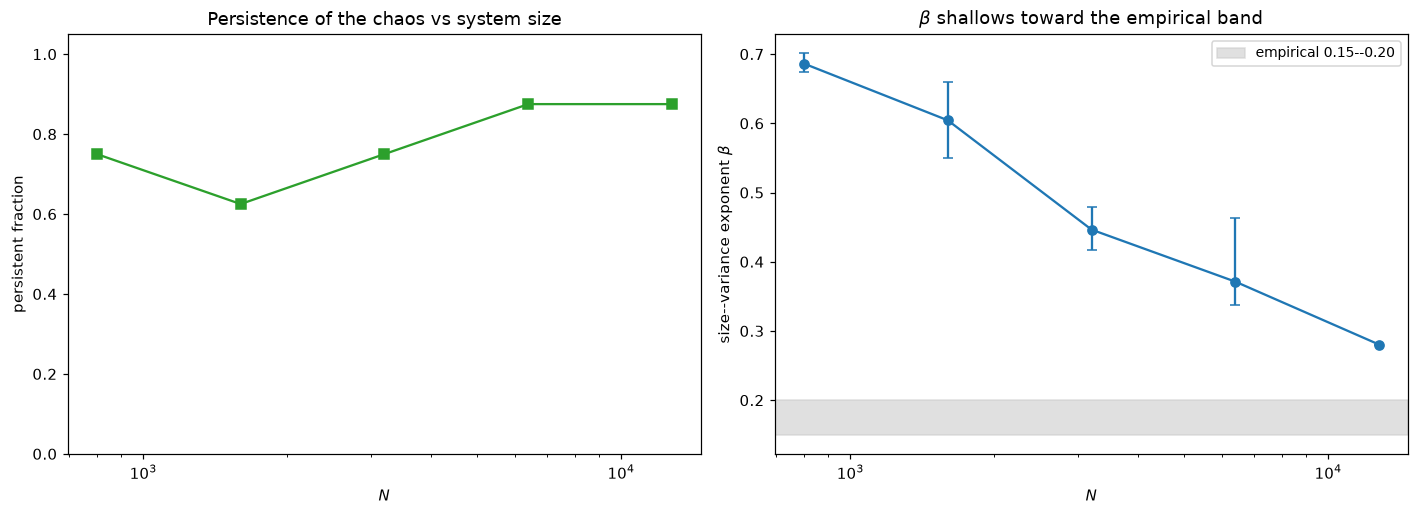

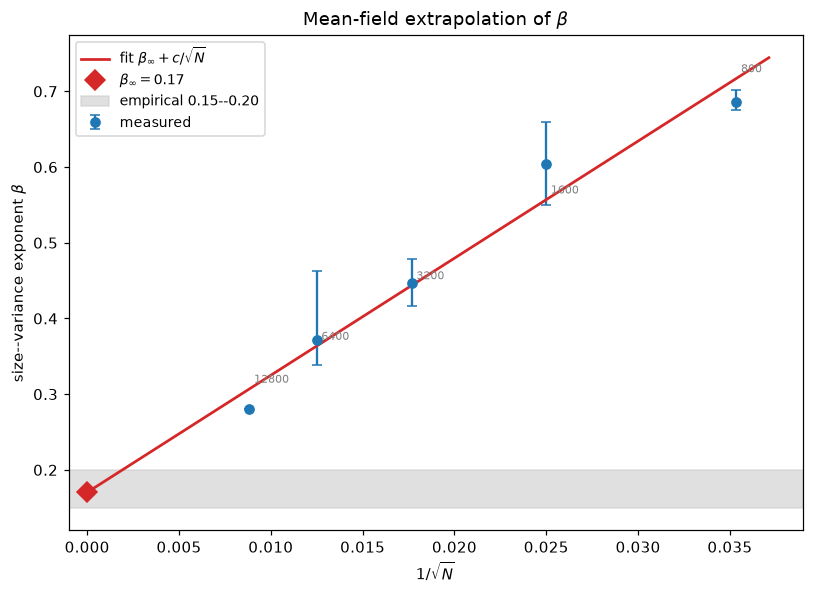

beta_inf = 0.170  (empirical band: 0.15-0.20)


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

N  = d["ns_N"].astype(float)
pf = d["ns_persistf"].astype(float)
b  = d["ns_beta"].astype(float)
lo = d["ns_blo"].astype(float)
hi = d["ns_bhi"].astype(float)

# ---- panel 1: persistence fraction vs N ----
ax[0].plot(N, pf, "s-", color="C2", ms=7)
ax[0].set(xscale="log", ylim=(0, 1.05),
          xlabel="$N$", ylabel="persistent fraction",
          title="Persistence of the chaos vs system size")

# ---- panel 2: beta vs N ----
m = np.isfinite(b)
ax[1].errorbar(N[m], b[m], yerr=[b[m] - lo[m], hi[m] - b[m]],
               fmt="o-", color="C0", capsize=3)
ax[1].axhspan(0.15, 0.20, color="0.8", alpha=0.6,
              label=r"empirical $0.15$--$0.20$")
ax[1].set(xscale="log", xlabel="$N$",
          ylabel=r"size--variance exponent $\beta$",
          title=r"$\beta$ shallows toward the empirical band")
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ---- beta extrapolation (separate figure) ----
fig2, ax2 = plt.subplots(figsize=(7.5, 5.5))
binf  = float(d["ns_beta_inf"])
slope = float(d["ns_beta_slope"])
x  = 1.0 / np.sqrt(N[m])
xx = np.linspace(0, x.max() * 1.05, 100)

ax2.errorbar(x, b[m], yerr=[b[m] - lo[m], hi[m] - b[m]],
             fmt="o", color="C0", capsize=3, label="measured")
ax2.plot(xx, binf + slope * xx, "C3-", lw=1.8,
         label=r"fit $\beta_\infty + c/\sqrt{N}$")
ax2.plot(0, binf, "D", color="C3", ms=9,
         label=f"$\\beta_\\infty={binf:.2f}$")
ax2.axhspan(0.15, 0.20, color="0.8", alpha=0.6,
            label=r"empirical $0.15$--$0.20$")
for xi, Ni in zip(x, N[m]):
    ax2.annotate(f"{int(Ni)}", (xi, binf + slope * xi), fontsize=7, color="0.5",
                 xytext=(3, 4), textcoords="offset points")
ax2.set(xlabel=r"$1/\sqrt{N}$",
        ylabel=r"size--variance exponent $\beta$",
        title=r"Mean-field extrapolation of $\beta$")
ax2.set_xlim(left=-0.001)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"beta_inf = {binf:.3f}  (empirical band: 0.15-0.20)")


## Phase diagram

The model has two control parameters:

- **Disorder $\sigma$**: above $\sigma_c = \sqrt{2}$ (from DMFT, see below) the
  replicator enters a **fluctuating phase** where firms' relative sizes never
  settle to a fixed point -- this is where the MSB tent lives.
- **Mean competition $\mu$**: sets the aggregate growth rate
  $g^* = g_0(\sigma) - \mu$.  For large $\mu$ the economy shrinks; for small $\mu$
  (or cooperation) it grows.

The scatter below classifies each $( \mu, \sigma )$ grid point as growing,
shrinking, or fast-growing, and as chaotic (circle) or frozen (square), based on
direct simulation.  The horizontal dashed line at $\sigma_c = \sqrt{2}$
is the DMFT prediction for the chaos onset -- it is **$\mu$-independent** because
$\mu$ is a uniform fitness shift that cancels from the replicator.


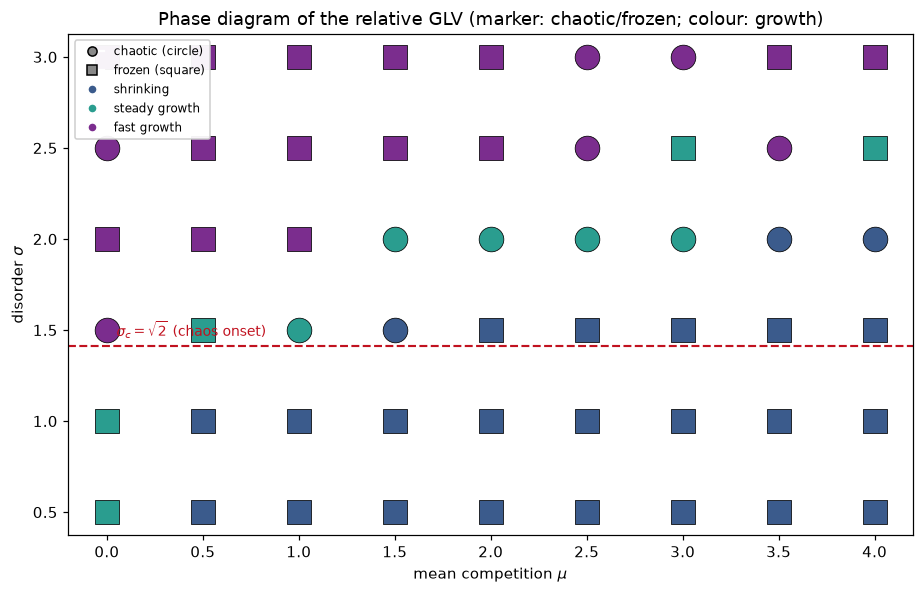

In [5]:
pd_data = np.load(DATA / "phase_diagram.npz", allow_pickle=True)
G    = pd_data["G"];  F    = pd_data["F"]
MUS  = pd_data["MUS"].tolist(); SIGS = pd_data["SIGS"].tolist()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for j, sig in enumerate(SIGS):
    for i, mu in enumerate(MUS):
        g, f = G[j, i], F[j, i]
        chaotic = f > 0.02
        if g < -0.05:
            c = "#3b5b8c"
        elif g > 5:
            c = "#7b2d8e"
        else:
            c = "#2a9d8f"
        ax.scatter(mu, sig, s=260, c=c,
                   marker=("o" if chaotic else "s"),
                   edgecolors="k", linewidths=0.5, zorder=3)

ax.axhline(np.sqrt(2), color="#c1121f", ls="--", lw=1.4, zorder=1)
ax.text(0.05, np.sqrt(2) + 0.05, r"$\sigma_c=\sqrt{2}$ (chaos onset)",
        color="#c1121f", fontsize=9)

leg = [
    Line2D([], [], marker="o", color="w", markerfacecolor="#888",
           markeredgecolor="k", label="chaotic (circle)"),
    Line2D([], [], marker="s", color="w", markerfacecolor="#888",
           markeredgecolor="k", label="frozen (square)"),
    Line2D([], [], marker="o", color="w", markerfacecolor="#3b5b8c",
           label="shrinking"),
    Line2D([], [], marker="o", color="w", markerfacecolor="#2a9d8f",
           label="steady growth"),
    Line2D([], [], marker="o", color="w", markerfacecolor="#7b2d8e",
           label="fast growth"),
]
ax.legend(handles=leg, loc="upper left", fontsize=8, framealpha=0.95)
ax.set(xlabel=r"mean competition $\mu$",
       ylabel=r"disorder $\sigma$",
       title="Phase diagram of the relative GLV (marker: chaotic/frozen; colour: growth)")
plt.tight_layout()
plt.show()


### Analytic phase structure (DMFT, live)

The DMFT solver computes the fixed-point observables $g_0(\sigma)$, $\varphi(\sigma)$
analytically.  The two panels below are fully live (no stored data):

- **Left**: predicted $(\mu, \sigma)$ phase diagram.  The $g^* = 0$ contour
  $\mu = g_0(\sigma)$ (blue curve) separates growing from shrinking in the relaxed
  phase.  Above $\sigma_c = \sqrt{2}$ (red dashed) the fixed point is unstable and
  the two-time DMFT is needed to compute the true growth rate.
- **Right**: $g_0(\sigma)$ and the survival fraction $\varphi(\sigma)$ as functions
  of disorder.  Both are $\mu$-independent because $\mu$ cancels from the replicator;
  $\mu$ only shifts $g^* = g_0 - \mu$.  Dotted lines indicate the unstable regime
  ($\sigma > \sigma_c$) where the fixed point exists mathematically but is not
  dynamically reachable.


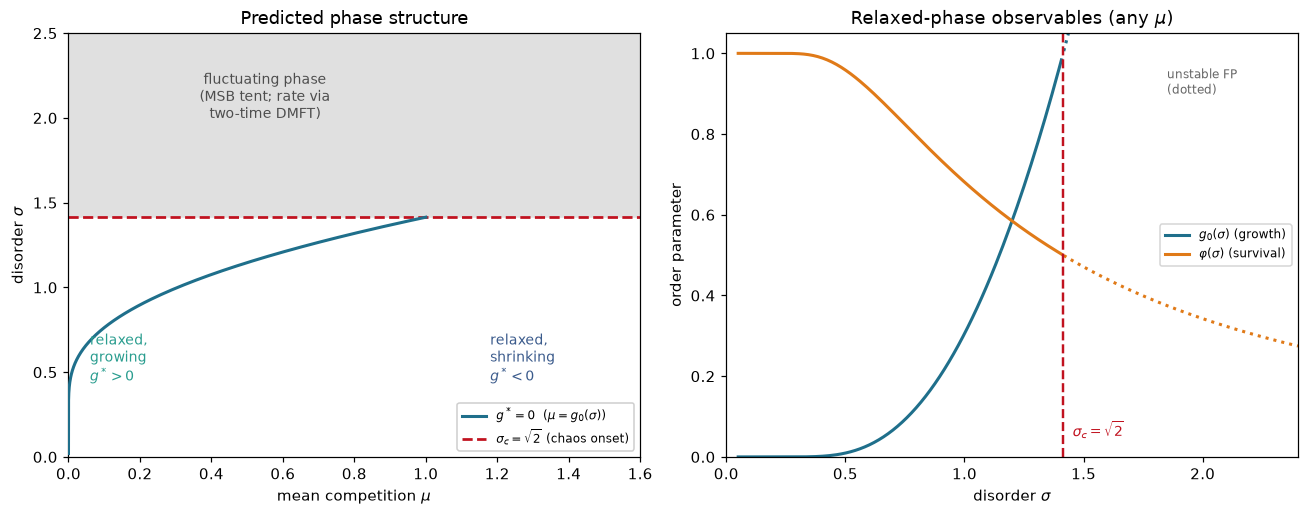

sigma_c = 1.4142  (= sqrt(2) = 1.4142)


In [6]:
from relative_glv import solve_fixed_point, sigma_c

sc = sigma_c(0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# ---- Panel A: (mu, sigma) predicted phase diagram ----
mu_max, sig_max = 1.6, 2.5
sig_relaxed = np.linspace(0.02, sc, 200)
g0_curve = np.array([solve_fixed_point(0.0, float(s))["g0"] for s in sig_relaxed])

axes[0].fill_between([0, mu_max], sc, sig_max, color="0.88", zorder=0)
axes[0].plot(g0_curve, sig_relaxed, color="#1f6f8b", lw=2, zorder=3,
             label=r"$g^*=0$  ($\mu=g_0(\sigma)$)")
axes[0].axhline(sc, color="#c1121f", ls="--", lw=1.8, zorder=2,
                label=r"$\sigma_c=\sqrt{2}$ (chaos onset)")
axes[0].text(0.06, 0.45, "relaxed,\ngrowing\n$g^*>0$", fontsize=9, color="#2a9d8f")
axes[0].text(1.18, 0.45, "relaxed,\nshrinking\n$g^*<0$", fontsize=9, color="#3b5b8c")
axes[0].text(0.55, 2.0, "fluctuating phase\n(MSB tent; rate via\ntwo-time DMFT)",
             fontsize=9, color="0.3", ha="center")
axes[0].set(xlabel=r"mean competition $\mu$", ylabel=r"disorder $\sigma$",
            xlim=(0, mu_max), ylim=(0, sig_max),
            title="Predicted phase structure")
axes[0].legend(loc="lower right", fontsize=8, framealpha=0.95)

# ---- Panel B: mu-independent order parameters vs sigma ----
sig_arr = np.linspace(0.05, 2.4, 240)
sol = [solve_fixed_point(0.0, float(s)) for s in sig_arr]
g0_arr  = np.array([s["g0"]  for s in sol])
phi_arr = np.array([s["phi"] for s in sol])
rel = sig_arr < sc

axes[1].plot(sig_arr[rel],  g0_arr[rel],  color="#1f6f8b", lw=2,
             label=r"$g_0(\sigma)$ (growth)")
axes[1].plot(sig_arr[~rel], g0_arr[~rel], color="#1f6f8b", lw=2, ls=":")
axes[1].plot(sig_arr[rel],  phi_arr[rel],  color="#e07a18", lw=2,
             label=r"$\varphi(\sigma)$ (survival)")
axes[1].plot(sig_arr[~rel], phi_arr[~rel], color="#e07a18", lw=2, ls=":")
axes[1].axvline(sc, color="#c1121f", ls="--", lw=1.6)
axes[1].text(sc + 0.04, 0.05, r"$\sigma_c=\sqrt{2}$", color="#c1121f", fontsize=9)
axes[1].text(1.85, 0.9, "unstable FP\n(dotted)", fontsize=8, color="0.4")
axes[1].set(xlabel=r"disorder $\sigma$", ylabel="order parameter",
            xlim=(0, 2.4), ylim=(0, 1.05),
            title=r"Relaxed-phase observables (any $\mu$)")
axes[1].legend(loc="center right", fontsize=8)

plt.tight_layout()
plt.show()
print(f"sigma_c = {sc:.4f}  (= sqrt(2) = {np.sqrt(2):.4f})")


## Appendix: DMFT in brief

In the high-connectivity limit the many-body dynamics reduce to a single-site
stochastic process.  The survivor's rescaled abundance satisfies

$$x^* = \frac{\sigma \sqrt{q}}{v} \max(\Delta + z,\, 0), \qquad z \sim \mathcal{N}(0,1),$$

where $\Delta$ is the clipping threshold, $q$ the disorder average of $(x^*)^2$,
and $v = 1 - \gamma \sigma^2 \chi$ the renormalised self-interaction (at
$\gamma = 0$, $v = 1$).  The self-consistency equations close on a single scalar
root for $\Delta$:

$$v^2 = \sigma^2\, w_2(\Delta), \qquad
  w_n(\Delta) = \int_{-\Delta}^\infty \mathcal{D}z\,(\Delta+z)^n.$$

The mean competition $\mu$ is a uniform fitness shift that cancels from the
replicator.  It appears only in the growth rate: $g^* = g_0(\sigma) - \mu$.
The relaxed-phase boundary follows from $w_0 = w_2$ (i.e. $\Delta = 0$,
$\varphi = 1/2$), giving the **$\mu$-independent critical disorder**

$$\boxed{\sigma_c = \sqrt{2}.}$$

Full derivation:
`glv/docs/superpowers/specs/2026-06-21-relative-glv-dmft-derivation.md`.

### Validation against matched simulation

The three panels below compare the DMFT fixed-point predictions against direct
simulation with fully-connected Gaussian couplings (the exact ensemble the DMFT
is derived for).  The match is within 1% in the relaxed phase ($\sigma < \sigma_c$).
Above $\sigma_c$ the fixed point is dynamically unstable; the two-time DMFT is
needed there.


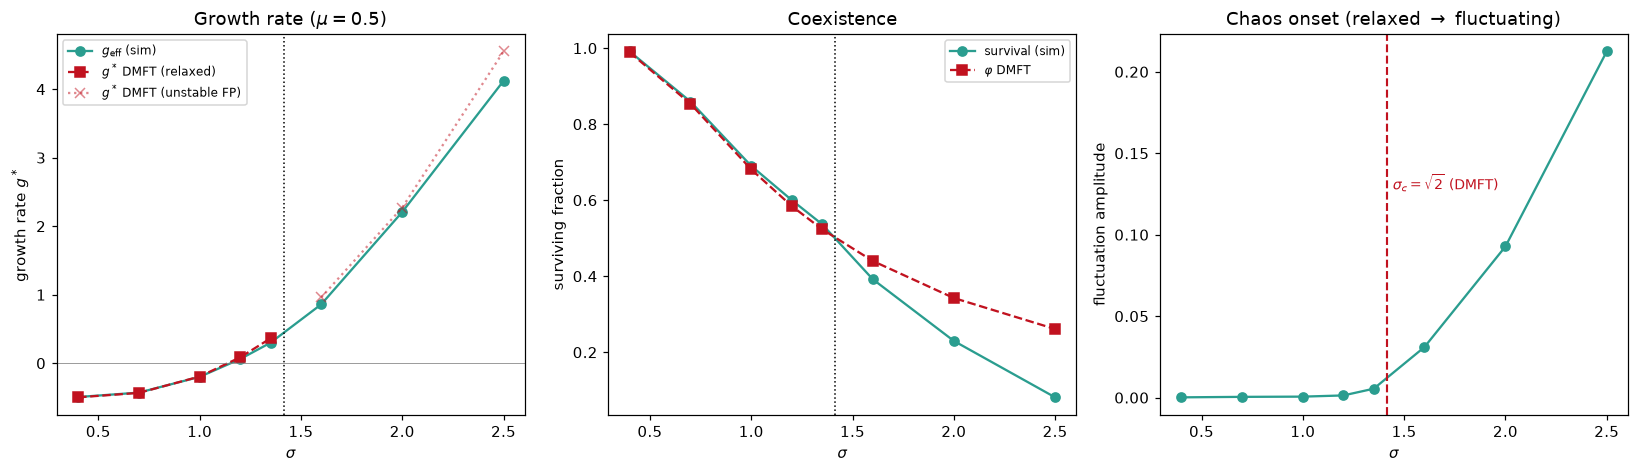

Relaxed-phase mean |g_eff - g*| = 0.020,  mean |surv - phi| = 0.009


In [7]:
dv = np.load(DATA / "dmft_validation.npz", allow_pickle=True)
sigmas   = dv["sigmas"]
sim_arr  = dv["sim"]      # shape (n_sigma, 3): g_eff, surv, fluct
mui_mus  = dv["mui_mus"]
mui_arr  = dv["mui"]      # shape (3, 3)

MU = 0.5   # the mu used for the sigma sweep
sc = sigma_c(0.0)

sim  = {float(s): sim_arr[i] for i, s in enumerate(sigmas)}
dm   = [solve_fixed_point(MU, float(s)) for s in sigmas]
gstar_arr = np.array([d["gstar"] for d in dm])
phi_arr   = np.array([d["phi"]   for d in dm])
rel       = sigmas < sc

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# ---- panel 1: growth rate ----
ax[0].plot(sigmas, [sim[s][0] for s in sigmas], "o-",
           label=r"$g_{\rm eff}$ (sim)", color="#2a9d8f")
ax[0].plot(sigmas[rel],  gstar_arr[rel],  "s--",
           label=r"$g^*$ DMFT (relaxed)", color="#c1121f")
ax[0].plot(sigmas[~rel], gstar_arr[~rel], "x:",
           label=r"$g^*$ DMFT (unstable FP)", color="#c1121f", alpha=0.5)
ax[0].axvline(sc, color="k", ls=":", lw=1)
ax[0].axhline(0, color="grey", lw=0.5)
ax[0].set(xlabel=r"$\sigma$", ylabel=r"growth rate $g^*$",
          title=f"Growth rate ($\\mu={MU}$)")
ax[0].legend(fontsize=8)

# ---- panel 2: coexistence ----
ax[1].plot(sigmas, [sim[s][1] for s in sigmas], "o-",
           label="survival (sim)", color="#2a9d8f")
ax[1].plot(sigmas, phi_arr, "s--",
           label=r"$\varphi$ DMFT", color="#c1121f")
ax[1].axvline(sc, color="k", ls=":", lw=1)
ax[1].set(xlabel=r"$\sigma$", ylabel="surviving fraction",
          title="Coexistence")
ax[1].legend(fontsize=8)

# ---- panel 3: chaos onset ----
fluct_arr = np.array([sim[s][2] for s in sigmas])
ax[2].plot(sigmas, fluct_arr, "o-", color="#2a9d8f")
ax[2].axvline(sc, color="#c1121f", ls="--", lw=1.4)
ax[2].text(sc + 0.03, 0.6 * max(fluct_arr.max(), 1e-6),
           r"$\sigma_c=\sqrt{2}$ (DMFT)", color="#c1121f", fontsize=9)
ax[2].set(xlabel=r"$\sigma$", ylabel="fluctuation amplitude",
          title=r"Chaos onset (relaxed $\to$ fluctuating)")

plt.tight_layout()
plt.show()

# quick sanity numbers
g_sim = np.array([sim[s][0] for s in sigmas])
s_sim = np.array([sim[s][1] for s in sigmas])
err_g = np.mean(np.abs(g_sim[rel] - gstar_arr[rel]))
err_s = np.mean(np.abs(s_sim[rel] - phi_arr[rel]))
print(f"Relaxed-phase mean |g_eff - g*| = {err_g:.3f},  mean |surv - phi| = {err_s:.3f}")
